**Using TensorBoard with PyTorch**

Need to install PyTorch, TorchVision, Matplotlib, TensorBoard with conda or pip

**Introduction**

training LeNet-5 against Fashion-MNIST set. Fashion-MNIST set of image tiles depicting various garments, with ten class labels indicating garment

In [14]:
import sys
!{sys.executable} -m pip install tensorboard
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#Img datasets and img manipulation
import torchvision
import torchvision.transforms as transforms

#Image display
import matplotlib.pyplot as pyplot
import numpy as numpy

#PyTorch tensorboard support
from torch.utils.tensorboard import SummaryWriter


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Showing images in TensorBoard**

Let's start by adding sample images from dataset to TensorBoard:

In [11]:
# gather datasets prepare for consumption

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,), (0.5,))])

#store seperate training and validation splits in ./data
training_set = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=transform)
validation_set = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                        download=True, transform=transform)

training_loader= torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True, num_workers=2)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

In [5]:
#helper function to display an image

def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        pyplot.imshow(npimg, cmap="Greys")
    else:
        pyplot.imshow(np.transpose(npimg, (1, 2, 0)))

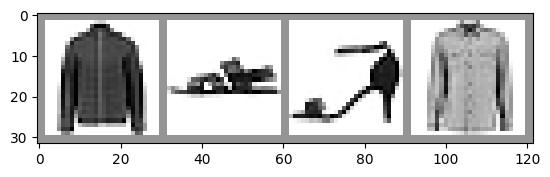

In [9]:
# Extract a batch of 4 images
dataiter = iter(training_loader)
images, labels = next(dataiter)     

# Create a grid from the batch
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)



Above, we used TorchVision and Matplotlib to create a visual grid of a mnibatch of our input data. Below, we use the `add_image()` call on `SummaryWriter` to log the image for consumption by TensorBoard, and we call `flush()` to make sure it's written to disk right away.

In [12]:
# Default log_dir argument is "runs" bit good to be specific about where we are writing to
writer = SummaryWriter('runs/fashion_mnist_experiment_1')

#Write data to TensorBoard log dir
writer.add_image('Four Fashion-MNIST Images', img_grid)
writer.flush()

# To view, start Tensorboard on command line with: tensorboard --logdir=runs ... and open a broswer tap to http://localhost:6006/

**Graphing Scalaras to Visualize Training**

TensorBoard useful for tracking the progress and efficacy of your training. Below, we'll run a training loop, track some metrics, save data for TensorBoard consumption.

Define a model to catogarize image tiles. 

In [16]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x = self.pool(F.relu(self.conv2(x))) 
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Now let's train a single epoch, and evaluate training vs validation set losses every 1000 batches

In [17]:
print (len(validation_loader))

for epoch in range(1):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(training_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i%1000 == 999:    # every 1000 mini-batches...
            print('Batch {}'.format(i + 1))
            running_vloss = 0.0

            net.train(False) # set model to evaluation mode
            for j, vdata in enumerate(validation_loader, 0):
                vinputs, vlabels = vdata
                voutputs = net(vinputs)
                vloss = criterion(voutputs, vlabels)
                running_vloss += vloss.item()
            net.train(True) # set model back to training mode

            avg_loss = running_loss / 1000
            avg_vloss = running_vloss / len(validation_loader)

            #Log running data averaged per batch

            writer.add_scalars('Training vs. Validation Loss',
                                {'Training' : avg_loss, 'Validation' : avg_vloss},
                                epoch * len(training_loader) + i)
            running_loss = 0.0
print('Finished Training')
writer.flush()


2500
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Finished Training


Switch to open TensorBoard and have a look at SCALARS tab.

**Visualizing Your Model**

TensorBoard can also be used to examine the data flow within your model. To do this, call the `add_graph()` method with a model and simple input. When you open

In [19]:
dataiter=iter(training_loader)
images, labels=next(dataiter)

writer.add_graph(net, images)
writer.flush()

switch over to TensorBoard, you should see a GRAPHS tab. Double-click the "Net" node to see the layers and data flow in model

**Visualizing Your Dataset with Embeddings**

28-by-28 image tiles we're using can be modeled as 784 dimensional vectors. Can be instructive to make lower dimension. `add_embedding()` method will project a set of data onto the three dimensions with highest variance, display them as an interactive 3D chart. `add_embedding()` method does this automatically projecting to the three dimensions with higest variance

In [22]:
# select a random subset of data

def select_n_random(data, labels, n=100):
    '''
    Selects n random datapoints and their corresponding labels from a dataset
    '''
    assert len(data) == len(labels)

    perm = torch.randperm(len(data))
    return data[perm][:n], labels[perm][:n]

images, labels = select_n_random(training_set.data, training_set.targets)

class_labels = [classes[label] for label in labels]

features=images.view(-1, 28*28)
writer.add_embedding(features,
                     metadata=class_labels,
                     label_img=images.unsqueeze(1))

writer.flush()
writer.close()

switch to TensorBoard and select PROJECTOR tab, should see a 3D representation of projection. Rotate zoom the model, examine it at large and small scales, see patterns cluster pattern. 